# Final Project: Music Genre Classification from Spectrograms (ResNet50 and Emotion Prediction)

**Goal:**  
Train a deep learning model (ResNet-50) to classify music genre from mel-spectrogram images generated from the GTZAN dataset.

**Core pipeline:**
1. Load GTZAN audio files.
2. Convert audio to mel-spectrograms using `librosa`.
3. Build a PyTorch `Dataset` that returns spectrogram tensors + genre labels.
4. Fine-tune a pretrained ResNet-50 for 10-way genre classification.
5. Evaluate with accuracy + confusion matrix and some visualizations.
6. Do Emotion Prediction using ResNet-50 on the DEAM dataset. 
7. Evaluate with confusion matrix for visualization.


In [127]:
import glob
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# for the Audio
import librosa
import librosa.display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [128]:
# Reproducibility
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# location of GTZAN dataset
GTZAN_ROOT = "Music Data/gtzan"  
print("GTZAN root:", GTZAN_ROOT)
print("Folders found:", os.listdir(GTZAN_ROOT))

genres = sorted([
    d for d in os.listdir(GTZAN_ROOT)
    if os.path.isdir(os.path.join(GTZAN_ROOT, d)) and not d.startswith(".")
])

print("Found genres:", genres)
print("Number of genres:", len(genres))

genre_to_idx = {g: i for i, g in enumerate(genres)}
idx_to_genre = {i: g for g, i in genre_to_idx.items()}
print("Genre to index mapping:", genre_to_idx)

all_files = []
for genre in genres:
    genre_dir = os.path.join(GTZAN_ROOT, genre)
    for fname in os.listdir(genre_dir):
        if fname.lower().endswith((".wav", ".au", ".mp3")):
            fpath = os.path.join(genre_dir, fname)
            all_files.append((fpath, genre_to_idx[genre]))


bad_path = os.path.join(GTZAN_ROOT, "jazz", "jazz.00054.wav")
all_files = [(p, l) for (p, l) in all_files if p != bad_path]

print("After removing broken file:", len(all_files))

print("Total audio files found:", len(all_files))
print("First 5 entries:")
for i in range(5):
    print(all_files[i])

Using device: cpu
GTZAN root: Music Data/gtzan
Folders found: ['pop', '.DS_Store', 'metal', 'disco', 'blues', 'reggae', 'classical', 'rock', 'hiphop', 'country', 'jazz']
Found genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Number of genres: 10
Genre to index mapping: {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}
After removing broken file: 999
Total audio files found: 999
First 5 entries:
('Music Data/gtzan/blues/blues.00093.wav', 0)
('Music Data/gtzan/blues/blues.00087.wav', 0)
('Music Data/gtzan/blues/blues.00050.wav', 0)
('Music Data/gtzan/blues/blues.00044.wav', 0)
('Music Data/gtzan/blues/blues.00078.wav', 0)


In [129]:
SAMPLE_RATE = 22050
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048
DURATION = 3.0    # number of second per model that we will feed
FMIN = 20
FMAX = 8000

def load_audio(path, sr=SAMPLE_RATE, duration=DURATION):
    target_len = int(sr * duration)

    try:
        y, orig_sr = librosa.load(path, sr=sr, mono=True)
    except Exception as e:
        print(f"Failed to load {path} ({type(e).__name__}: {e}). Using silence instead.")
        y = np.zeros(target_len, dtype=np.float32)
        return y, sr

    # trim/pad to fixed duration
    if len(y) > target_len:
        start = np.random.randint(0, len(y) - target_len)
        y = y[start:start + target_len]
    elif len(y) < target_len:
        pad_width = target_len - len(y)
        y = np.pad(y, (0, pad_width), mode="constant")

    return y, sr


def audio_to_mel_spectrogram(y, sr=SAMPLE_RATE, n_mels=N_MELS):
    # convert waveform to mel spectrogram in dB
    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=n_mels,
        fmin=FMIN,
        fmax=FMAX
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db


Testing file: Music Data/gtzan/blues/blues.00022.wav
Label index: 0  -> genre: blues
Waveform shape: (66150,)  sample rate: 22050
Spectrogram shape (mel x time): (128, 130)


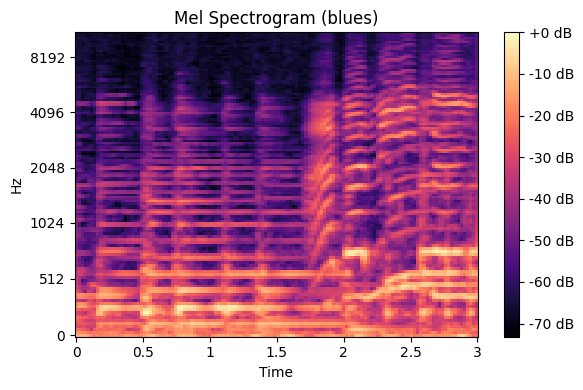

In [130]:
# do the test on one random file to check the functions if they work
test_path, test_label = random.choice(all_files)
print("Testing file:", test_path)
print("Label index:", test_label, " -> genre:", idx_to_genre[test_label])

y_test, sr_test = load_audio(test_path)
print("Waveform shape:", y_test.shape, " sample rate:", sr_test)

S_db_test = audio_to_mel_spectrogram(y_test, sr_test)
print("Spectrogram shape (mel x time):", S_db_test.shape)

plt.figure(figsize=(6,4))
librosa.display.specshow(S_db_test, sr=sr_test, hop_length=HOP_LENGTH,
                         x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel Spectrogram ({idx_to_genre[test_label]})")
plt.tight_layout()
plt.show()

In [131]:
# generate the spctrogram for simplicity so we can later use them in case runtime is slow
class GTZANSpectrogramDataset(Dataset):
    def __init__(self, file_label_list):
        """
        file_label_list: list of (audio_path, class_index) tuples.
        We'll:
          - load the audio
          - convert to mel-spectrogram
          - normalize it
          - make it 3-channel so ResNet can use it
        """
        self.file_label_list = file_label_list

    def __len__(self):
        return len(self.file_label_list)

    def __getitem__(self, idx):
        path, label = self.file_label_list[idx]

        # sample rate and duration from earlier in the sections
        y, sr = load_audio(path)  

        # Convert waveform to log-mel spectrogram
        S_db = audio_to_mel_spectrogram(y, sr)

        # Normalize spectrogram values to [0,1]
        S_min, S_max = S_db.min(), S_db.max()
        S_norm = (S_db - S_min) / (S_max - S_min + 1e-8)

        # Convert to tensor, add channel dimension and repeat to 3 channels
        S_tensor = torch.tensor(S_norm, dtype=torch.float32)
        S_tensor = S_tensor.unsqueeze(0)           # (1, H, W)
        S_tensor = S_tensor.repeat(3, 1, 1)        # (3, H, W)

        label = torch.tensor(label, dtype=torch.long)
        return S_tensor, label


# split into train, val, test
random.shuffle(all_files)  # shuffle in-place

N = len(all_files)
n_train = int(0.8 * N)
n_val   = int(0.1 * N)
n_test  = N - n_train - n_val

train_files = all_files[:n_train]
val_files   = all_files[n_train:n_train+n_val]
test_files  = all_files[n_train+n_val:]

print("Split sizes -> train:", len(train_files),
      " val:", len(val_files),
      " test:", len(test_files))

# Create datasets
train_dataset = GTZANSpectrogramDataset(train_files)
val_dataset   = GTZANSpectrogramDataset(val_files)
test_dataset  = GTZANSpectrogramDataset(test_files)

# DataLoaders
BATCH_SIZE = 10
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# get one batch to check
xb, yb = next(iter(train_loader))
print("Batch spectrograms shape:", xb.shape)  # (B, 3, H, W)
print("Batch labels shape:", yb.shape)        # (B,)
print("First 8 labels (indices):", yb[:8].tolist())
print("First 8 labels (genres):", [idx_to_genre[int(i)] for i in yb[:8]])


Split sizes -> train: 799  val: 99  test: 101
Batch spectrograms shape: torch.Size([10, 3, 128, 130])
Batch labels shape: torch.Size([10])
First 8 labels (indices): [5, 9, 7, 7, 6, 8, 5, 4]
First 8 labels (genres): ['jazz', 'rock', 'pop', 'pop', 'metal', 'reggae', 'jazz', 'hiphop']


In [132]:
num_classes = 10  

weights = models.ResNet50_Weights.IMAGENET1K_V2
model = models.resnet50(weights=weights)

# Replace only the final fc layer
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(DEVICE)


In [133]:
# set up the reusable functions similar to ones we used in previous homeworks
def train_one_epoch(model, loader, optimizer, criterion, device=DEVICE):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)           
        loss = criterion(outputs, yb)  

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        _, preds = torch.max(outputs, 1)   # argmax over classes
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


def eval_one_epoch(model, loader, criterion, device=DEVICE):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)
            loss = criterion(outputs, yb)

            running_loss += loss.item() * xb.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


In [134]:
EPOCHS = 30  # increased based on accuracy

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Cosine decay over all epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6,
)

criterion = nn.CrossEntropyLoss()

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
best_state = None

for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = eval_one_epoch(model, val_loader, criterion)

    # step the scheduler AFTER each epoch
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()

    print(f"[Epoch {ep:02d}] "
          f"lr={current_lr:.6f} | "
          f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
          f"val loss={val_loss:.4f} acc={val_acc:.3f}")

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded best model with val acc={best_val_acc:.3f}")


[Epoch 01] lr=0.000100 | train loss=2.1907 acc=0.229 | val loss=2.1742 acc=0.283
[Epoch 02] lr=0.000099 | train loss=1.7333 acc=0.421 | val loss=1.5746 acc=0.455
[Epoch 03] lr=0.000098 | train loss=1.3305 acc=0.574 | val loss=1.2302 acc=0.566
[Epoch 04] lr=0.000096 | train loss=1.2111 acc=0.612 | val loss=1.3453 acc=0.586
[Epoch 05] lr=0.000093 | train loss=1.1330 acc=0.632 | val loss=1.2748 acc=0.556
[Epoch 06] lr=0.000091 | train loss=0.9632 acc=0.677 | val loss=1.0304 acc=0.616
[Epoch 07] lr=0.000087 | train loss=0.9236 acc=0.680 | val loss=1.2777 acc=0.626
[Epoch 08] lr=0.000084 | train loss=0.8338 acc=0.725 | val loss=1.0784 acc=0.667
[Epoch 09] lr=0.000080 | train loss=0.7541 acc=0.758 | val loss=0.9405 acc=0.687
[Epoch 10] lr=0.000075 | train loss=0.7199 acc=0.760 | val loss=0.9810 acc=0.657
[Epoch 11] lr=0.000071 | train loss=0.6995 acc=0.778 | val loss=1.2721 acc=0.657
[Epoch 12] lr=0.000066 | train loss=0.5986 acc=0.805 | val loss=1.0309 acc=0.707
[Epoch 13] lr=0.000061 | tra

Test loss=0.5488, test acc=0.812
Confusion matrix (rows = true, cols = predicted):
[[10  0  2  0  0  0  0  0  0  1]
 [ 0  8  0  0  0  0  0  0  0  0]
 [ 1  0  5  0  0  0  0  0  0  0]
 [ 0  0  0 10  0  0  0  1  0  0]
 [ 1  0  1  0  9  0  0  0  1  0]
 [ 1  0  0  0  0 10  0  0  0  0]
 [ 0  0  0  0  1  0  9  0  0  0]
 [ 0  0  0  0  0  0  0  5  2  0]
 [ 0  0  0  1  1  0  0  0 10  0]
 [ 0  0  3  0  0  0  1  0  0  7]]


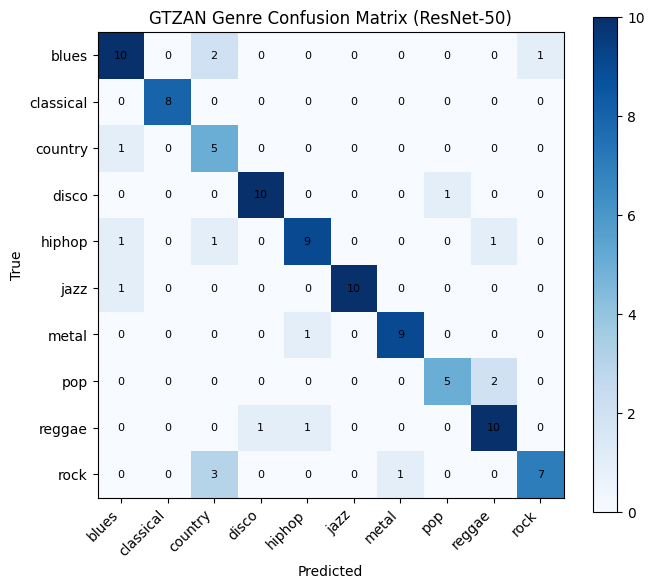

In [137]:
# build the confusion matrix on test set

model.eval()
test_loss, test_acc = eval_one_epoch(model, test_loader, criterion)
print(f"Test loss={test_loss:.4f}, test acc={test_acc:.3f}")

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = model(xb)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(yb.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

num_classes = 10
cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(all_labels, all_preds):
    cm[t, p] += 1

print("Confusion matrix (rows = true, cols = predicted):")
print(cm)

genre_names = [idx_to_genre[i] for i in range(num_classes)]

fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(genre_names, rotation=45, ha="right")
ax.set_yticklabels(genre_names)

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j],
                ha="center", va="center", color="black", fontsize=8)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("GTZAN Genre Confusion Matrix (ResNet-50)")
plt.colorbar(im)
plt.tight_layout()
plt.show()


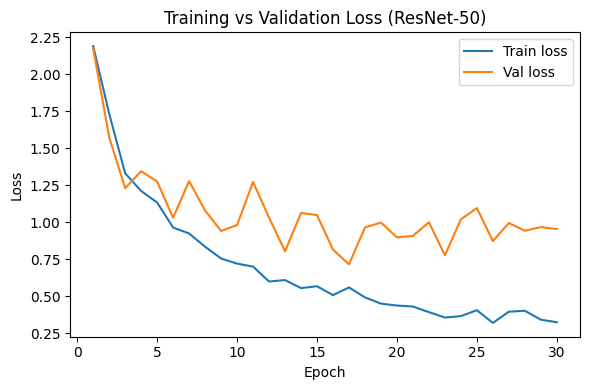

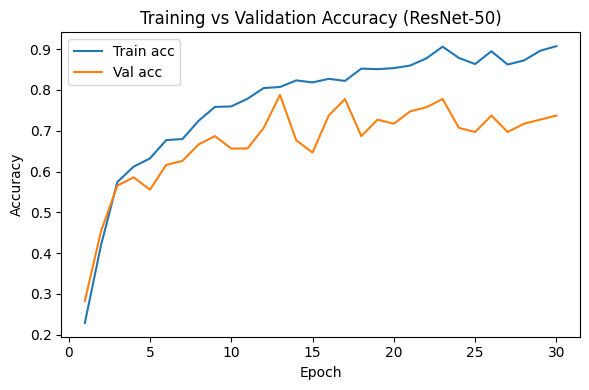

In [138]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (ResNet-50)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, train_accs, label="Train acc")
plt.plot(epochs, val_accs,   label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (ResNet-50)")
plt.legend()
plt.tight_layout()
plt.show()


In [121]:
# now we will work on the emotion prediction

DEAM_ROOT = "Music Data/deam"

ann_dir = os.path.join(
    DEAM_ROOT,
    "annotations",
    "annotations averaged per song",
    "song_level"
)

csv1 = os.path.join(ann_dir, "static_annotations_averaged_songs_1_2000.csv")
csv2 = os.path.join(ann_dir, "static_annotations_averaged_songs_2000_2058.csv")

ann1 = pd.read_csv(csv1)
ann2 = pd.read_csv(csv2)

# Strip whitespace from column names
ann1.columns = ann1.columns.str.strip()
ann2.columns = ann2.columns.str.strip()

ann = pd.concat([ann1, ann2], ignore_index=True)
print(f"Total annotations: {ann.shape}")
print(f"\nColumn names with whitespace stripped:")
print(ann.columns.tolist())

# Now try with the expected column names
VAL_COL = "valence_mean"   
ARO_COL = "arousal_mean"   
ID_COL  = "song_id"   

print(ann[[ID_COL, VAL_COL, ARO_COL]].head())

Total annotations: (1802, 13)

Column names with whitespace stripped:
['song_id', 'valence_mean', 'valence_std', 'arousal_mean', 'arousal_std', 'valence_ max_mean', 'valence_max_std', 'valence_min_mean', 'valence_min_std', 'arousal_max_mean', 'arousal_max_std', 'arousal_min_mean', 'arousal_min_std']
   song_id  valence_mean  arousal_mean
0        2           3.1           3.0
1        3           3.5           3.3
2        4           5.7           5.5
3        5           4.4           5.3
4        7           5.8           6.4


In [51]:
# create the 4 emotion quadrants
v_min, v_max = ann[VAL_COL].min(), ann[VAL_COL].max()
a_min, a_max = ann[ARO_COL].min(), ann[ARO_COL].max()

v_thr = 0.5 * (v_min + v_max)
a_thr = 0.5 * (a_min + a_max)

print("Valence range:", v_min, "to", v_max, " -> thr:", v_thr)
print("Arousal range:", a_min, "to", a_max, " -> thr:", a_thr)

def va_to_quadrant(v, a, v_thr=v_thr, a_thr=a_thr):
    if v >= v_thr and a >= a_thr:
        return 0 
    elif v >= v_thr and a < a_thr:
        return 1 
    elif v < v_thr and a < a_thr:
        return 2  
    else:
        return 3  

ann["emotion_label"] = [
    va_to_quadrant(v, a) for v, a in zip(ann[VAL_COL], ann[ARO_COL])
]

print(ann["emotion_label"].value_counts().sort_index())

Valence range: 1.6 to 8.4  -> thr: 5.0
Arousal range: 1.6 to 8.1  -> thr: 4.85
emotion_label
0    662
1    225
2    664
3    251
Name: count, dtype: int64


In [59]:
AUDIO_DIR = os.path.join(DEAM_ROOT, "audio")

print("Audio directory:", AUDIO_DIR)
print("Subfolders:", os.listdir(AUDIO_DIR)[:20])

for root, dirs, files in os.walk(AUDIO_DIR):
    print("ROOT:", root)
    print("  dirs:", dirs[:5])
    print("  files:", files[:5])
    break   

file_label_pairs = []
missing = 0

# Check what the song_id values look like
print("\nSample song_ids from annotations:")
print(ann[ID_COL].head(10).tolist())
print(f"Song ID type: {type(ann[ID_COL].iloc[0])}")

for _, row in ann.iterrows():
    sid = row[ID_COL]
    label = int(row["emotion_label"])
    
    # Convert song_id to integer then to string to handle any formatting issues
    sid_str = str(int(sid))
    
    # Look for exact match with .mp3 extension
    audio_path = os.path.join(AUDIO_DIR, f"{sid_str}.mp3")
    
    if os.path.exists(audio_path):
        file_label_pairs.append((audio_path, label))
    else:
        # Try .wav extension
        audio_path = os.path.join(AUDIO_DIR, f"{sid_str}.wav")
        if os.path.exists(audio_path):
            file_label_pairs.append((audio_path, label))
        else:
            missing += 1

print("Total matched DEAM tracks:", len(file_label_pairs))
print("Missing:", missing)
print("First 5:", file_label_pairs[:5])


# Distribution of emotion labels
if len(file_label_pairs) > 0:
    labels = [label for _, label in file_label_pairs]
    print(f"\nEmotion label distribution:")
    from collections import Counter
    print(Counter(labels))


Audio directory: Music Data/deam/audio
Subfolders: ['746.mp3', '1588.mp3', '1563.mp3', '1205.mp3', '791.mp3', '949.mp3', '1211.mp3', '1577.mp3', '2056.mp3', '1239.mp3', '961.mp3', '2042.mp3', '550.mp3', '236.mp3', '222.mp3', '544.mp3', '1946.mp3', '1952.mp3', '1007.mp3', '1761.mp3']
ROOT: Music Data/deam/audio
  dirs: []
  files: ['746.mp3', '1588.mp3', '1563.mp3', '1205.mp3', '791.mp3']

Sample song_ids from annotations:
[2, 3, 4, 5, 7, 8, 10, 12, 13, 17]
Song ID type: <class 'numpy.int64'>
Total matched DEAM tracks: 1802
Missing: 0
First 5: [('Music Data/deam/audio/2.mp3', 2), ('Music Data/deam/audio/3.mp3', 2), ('Music Data/deam/audio/4.mp3', 0), ('Music Data/deam/audio/5.mp3', 3), ('Music Data/deam/audio/7.mp3', 0)]

Emotion label distribution:
Counter({2: 664, 0: 662, 3: 251, 1: 225})


In [60]:
from sklearn.model_selection import train_test_split
import numpy as np

paths = [p for (p, lbl) in file_label_pairs]
labels = [lbl for (p, lbl) in file_label_pairs]

paths = np.array(paths)
labels = np.array(labels)

train_paths, val_paths, train_labels, val_labels = train_test_split(
        paths, labels,
        test_size=0.2,
        random_state=123,
        stratify=labels,      
    )

print("DEAM train:", train_paths.shape, train_labels.shape)
print("DEAM val  :", val_paths.shape,   val_labels.shape)

num_emotions = int(labels.max() + 1)
print("Number of emotion classes:", num_emotions)


DEAM train: (1441,) (1441,)
DEAM val  : (361,) (361,)
Number of emotion classes: 4


In [79]:
import librosa
import numpy as np
import torch
import torch.nn.functional as F

def audio_to_mel_spectrogram(
    path,
    sr=22050,
    n_mels=128,
    hop_length=512,
    duration=None,
    target_size=(128, 128),
):
    try:
        y, orig_sr = librosa.load(path, sr=sr, mono=True, duration=duration)
    except Exception as e:
        print(f"Failed to load {path} ({e}). Using silence instead.")
        T = int(sr * (duration if duration is not None else 3.0))
        y = np.zeros(T, dtype=np.float32)

    if y.size == 0:
        T = int(sr * (duration if duration is not None else 3.0))
        y = np.zeros(T, dtype=np.float32)

    # Mel-spectrogram
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=2048,
        hop_length=hop_length,
        n_mels=n_mels
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Convert to tensor with shape (H, W)
    x = torch.tensor(mel_db, dtype=torch.float32)
    x = x.unsqueeze(0)
    
    # Resize to target size if needed
    if target_size is not None:
        x = x.unsqueeze(0)
        x = F.interpolate(x, size=target_size, mode="bilinear", align_corners=False)
        x = x.squeeze(0)

    return x  # Shape: (1, 128, 128)

In [107]:
from torch.utils.data import Dataset, DataLoader
import torch

class DEAMEmotionDataset(Dataset):
    def __init__(self, paths, labels, sr=22050, n_mels=128, hop_length=512, duration=15.0, augment=False):
        """
        paths: list of audio file paths
        labels: list of corresponding emotion labels
        """
        self.paths = paths
        self.labels = labels
        self.sr = sr
        self.n_mels = n_mels
        self.hop_length = hop_length
        self.duration = duration
        self.augment = augment
        
        assert len(paths) == len(labels), "Paths and labels must have the same length"

    def __len__(self):
        return len(self.paths)
    
    def _augment_mel(self, mel: torch.Tensor) -> torch.Tensor:
        C, H, W = mel.shape

        # Random small time shift (horizontal roll)
        if torch.rand(1) < 0.5:
            max_shift = W // 10  # up to 10% of width
            shift = int(torch.randint(-max_shift, max_shift + 1, (1,)))
            mel = torch.roll(mel, shifts=shift, dims=2)

        if torch.rand(1) < 0.5:
            max_mask = H // 8
            mask_size = int(torch.randint(1, max_mask + 1, (1,)))
            start = int(torch.randint(0, H - mask_size, (1,)))
            mel[:, start:start+mask_size, :] = 0.0

        if torch.rand(1) < 0.5:
            max_mask_t = W // 8
            mask_t = int(torch.randint(1, max_mask_t + 1, (1,)))
            start_t = int(torch.randint(0, W - mask_t, (1,)))
            mel[:, :, start_t:start_t+mask_t] = 0.0

        return mel

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]
        
        mel = audio_to_mel_spectrogram(
            path,
            sr=self.sr,
            n_mels=self.n_mels,
            hop_length=self.hop_length,
            duration=self.duration,
            target_size=(128, 128),
        )
        if isinstance(mel, np.ndarray):
            mel = torch.from_numpy(mel)

        if mel.dim() == 2:
            mel = mel.unsqueeze(0)

        if mel.shape[0] == 1:
            mel = mel.repeat(3, 1, 1)

        mel = mel.to(torch.float32)
        
        if self.augment:
            mel = self._augment_mel(mel)

        label_t = torch.tensor(label, dtype=torch.long)
        return mel, label_t


# Create the datasets with separate path and label lists
deam_train_ds = DEAMEmotionDataset(train_paths, train_labels, duration=5.0, augment=True)
deam_val_ds   = DEAMEmotionDataset(val_paths,   val_labels,   duration=5.0, augment=False)

BATCH_SIZE = 32

deam_train_loader = DataLoader(
    deam_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

deam_val_loader = DataLoader(
    deam_val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print("DEAM loaders ready:",
      len(deam_train_loader), "train batches,",
      len(deam_val_loader), "val batches")

emotion_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for name, param in emotion_model.named_parameters():
    # freeze everything except layer3, layer4, fc
    if not any(k in name for k in ["layer3", "layer4", "fc"]):
        param.requires_grad = False

in_features = emotion_model.fc.in_features

emotion_model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.5),      
    nn.Linear(256, num_emotions),
)

emotion_model = emotion_model.to(DEVICE)

print("ResNet-50 initialized with:", num_emotions, "output classes")
xb, yb = next(iter(deam_train_loader))
print("Batch X shape:", xb.shape)   # should be [B, 3, 128, 128]
print("Batch y shape:", yb.shape)   # should be [B]

xb = xb.to(DEVICE)
out = emotion_model(xb)
print("Model output shape:", out.shape)  # [B, num_emotions]



DEAM loaders ready: 46 train batches, 12 val batches
ResNet-50 initialized with: 4 output classes
Batch X shape: torch.Size([32, 3, 128, 128])
Batch y shape: torch.Size([32])
Model output shape: torch.Size([32, 4])


In [108]:
import torch.optim as optim
import torch.nn as nn
from collections import Counter

EPOCHS = 30

# train_labels is your list/array of integer labels for DEAM train set
label_counts = Counter(train_labels)
num_classes = num_emotions  # already defined

N = len(train_labels)
weights = []
for c in range(num_classes):
    # higher weight for minority classes
    weights.append(N / (label_counts[c] + 1e-6))

class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
print("Class weights:", class_weights)

criterion_em = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1  # small smoothing, helps generalization a bit
)

optimizer_em = optim.AdamW(
    filter(lambda p: p.requires_grad, emotion_model.parameters()),
    lr=3e-5,
    weight_decay=5e-4
)

scheduler_em = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_em, 
    T_max=EPOCHS, 
    eta_min=1e-6
)

Class weights: tensor([2.7240, 8.0056, 2.7137, 7.1692])


In [109]:
best_val_acc_em = 0.0
best_state_em = None

for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(emotion_model, deam_train_loader, optimizer_em, criterion_em)
    val_loss, val_acc = eval_one_epoch(emotion_model, deam_val_loader, criterion_em)

    scheduler_em.step()

    if val_acc > best_val_acc_em:
        best_val_acc_em = val_acc
        best_state_em = emotion_model.state_dict()

    print(f"[DEAM Epoch {ep:02d}] "
          f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
          f"val loss={val_loss:.4f} acc={val_acc:.3f}")

if best_state_em is not None:
    emotion_model.load_state_dict(best_state_em)
    print(f"Loaded best DEAM model with val acc={best_val_acc_em:.3f}")


[DEAM Epoch 01] train loss=1.4157 acc=0.318 | val loss=1.3674 acc=0.366
[DEAM Epoch 02] train loss=1.3297 acc=0.473 | val loss=1.3028 acc=0.463
[DEAM Epoch 03] train loss=1.2745 acc=0.508 | val loss=1.2715 acc=0.562
[DEAM Epoch 04] train loss=1.2025 acc=0.608 | val loss=1.2554 acc=0.501
[DEAM Epoch 05] train loss=1.1671 acc=0.607 | val loss=1.2672 acc=0.543
[DEAM Epoch 06] train loss=1.1177 acc=0.643 | val loss=1.2835 acc=0.515
[DEAM Epoch 07] train loss=1.0570 acc=0.664 | val loss=1.2968 acc=0.540
[DEAM Epoch 08] train loss=0.9879 acc=0.711 | val loss=1.3117 acc=0.524
[DEAM Epoch 09] train loss=0.9234 acc=0.745 | val loss=1.3784 acc=0.512
[DEAM Epoch 10] train loss=0.8999 acc=0.758 | val loss=1.4050 acc=0.537
[DEAM Epoch 11] train loss=0.8300 acc=0.790 | val loss=1.4271 acc=0.562
[DEAM Epoch 12] train loss=0.8062 acc=0.807 | val loss=1.4507 acc=0.565
[DEAM Epoch 13] train loss=0.7504 acc=0.840 | val loss=1.5168 acc=0.562
[DEAM Epoch 14] train loss=0.7064 acc=0.865 | val loss=1.5171 ac

In [110]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, classification_report

emotion_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in deam_val_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = emotion_model(xb)              
        preds  = torch.argmax(logits, dim=1)    

        all_preds.append(preds.cpu())
        all_labels.append(yb.cpu())

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

val_acc = (all_preds == all_labels).mean()
print(f"Final DEAM validation accuracy: {val_acc:.3f}")

emotion_names = [
    "low_arousal_negative",
    "low_arousal_positive",
    "high_arousal_negative",
    "high_arousal_positive",
]

Final DEAM validation accuracy: 0.557


Confusion matrix (rows = true, cols = predicted):
 [[76 19 15 23]
 [ 8 16 14  7]
 [ 9 13 95 16]
 [10 11 15 14]]

Classification report:
                       precision    recall  f1-score   support

 low_arousal_negative       0.74      0.57      0.64       133
 low_arousal_positive       0.27      0.36      0.31        45
high_arousal_negative       0.68      0.71      0.70       133
high_arousal_positive       0.23      0.28      0.25        50

             accuracy                           0.56       361
            macro avg       0.48      0.48      0.48       361
         weighted avg       0.59      0.56      0.57       361



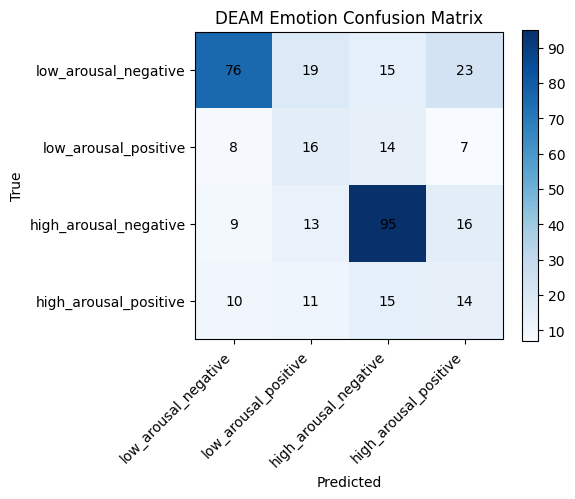

In [111]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix (rows = true, cols = predicted):\n", cm)

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=emotion_names))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(emotion_names)))
ax.set_yticks(range(len(emotion_names)))
ax.set_xticklabels(emotion_names, rotation=45, ha="right")
ax.set_yticklabels(emotion_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color="black", fontsize=10)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("DEAM Emotion Confusion Matrix")
plt.colorbar(im)
plt.tight_layout()
plt.show()
